Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_curve, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn import neighbors
from math import sqrt
from sklearn.tree import export_graphviz
import graphviz
from IPython.display import display
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

Data Pre processing

In [ ]:
c1=pd.read_csv('/content/consumer_classification_dataset.csv')
c2=pd.read_csv('/content/consumer_classification_dataset.csv')

In [ ]:
c2.head(7)

,Age,Income,Gender,Marital_Status,Credit_Score,Num_Purchases,Membership_Years,Device_Used,Churn
0,56.0,70201.189680,Female,Married,687.761776,9,12,Desktop,0
1,69.0,51901.897395,Male,Single,712.617115,3,14,Tablet,0
2,46.0,38605.409293,Male,Married,782.299643,5,8,Mobile,0
3,32.0,49949.736955,Female,Single,697.749518,7,1,Tablet,0
4,NaN,48965.290095,Other,Married,663.155216,4,4,Desktop,1
5,25.0,11326.768555,Female,Divorced,697.061084,1,4,Desktop,1
6,38.0,41579.497114,NaN,Divorced,687.615220,5,6,Tablet,1


In [ ]:
c1.isnull()

,Age,Income,Gender,Marital_Status,Credit_Score,Num_Purchases,Membership_Years,Device_Used,Churn
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
1495,False,False,False,False,False,False,False,False,False
1496,False,False,False,False,False,False,False,False,False
1497,False,False,False,False,False,False,False,False,False
1498,False,False,False,False,False,False,False,False,False


In [ ]:
c1.isnull().sum()

,0
Age,75
Income,75
Gender,75
Marital_Status,0
Credit_Score,75
Num_Purchases,0
Membership_Years,0
Device_Used,0
Churn,0


In [ ]:
print(c2['Gender'].unique())
print(c2['Marital_Status'].unique())
print(c2['Device_Used'].unique())

['Female' 'Male' 'Other' nan]
['Married' 'Single' 'Divorced']
['Desktop' 'Tablet' 'Mobile']


In [ ]:
print(f"The number of features in this dataset is {c1.shape[1]}")
#print("It is a Classification problem as the target variable is either 0 or 1.")
print(f"There are {c1.size} data points")
print(set(c1.dtypes))

The number of features in this dataset is 9
There are 13500 data points
{dtype('O'), dtype('float64'), dtype('int64')}


In [ ]:
print ('Shape of the dataset is {}. This dataset contains {} rows and {} columns.'.format(c1.shape,c1.shape[0],c1.shape[1]))

Shape of the dataset is (1500, 9). This dataset contains 1500 rows and 9 columns.


array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Income'}>],
       [<Axes: title={'center': 'Credit_Score'}>,
        <Axes: title={'center': 'Num_Purchases'}>],
       [<Axes: title={'center': 'Membership_Years'}>,
        <Axes: title={'center': 'Churn'}>]], dtype=object)

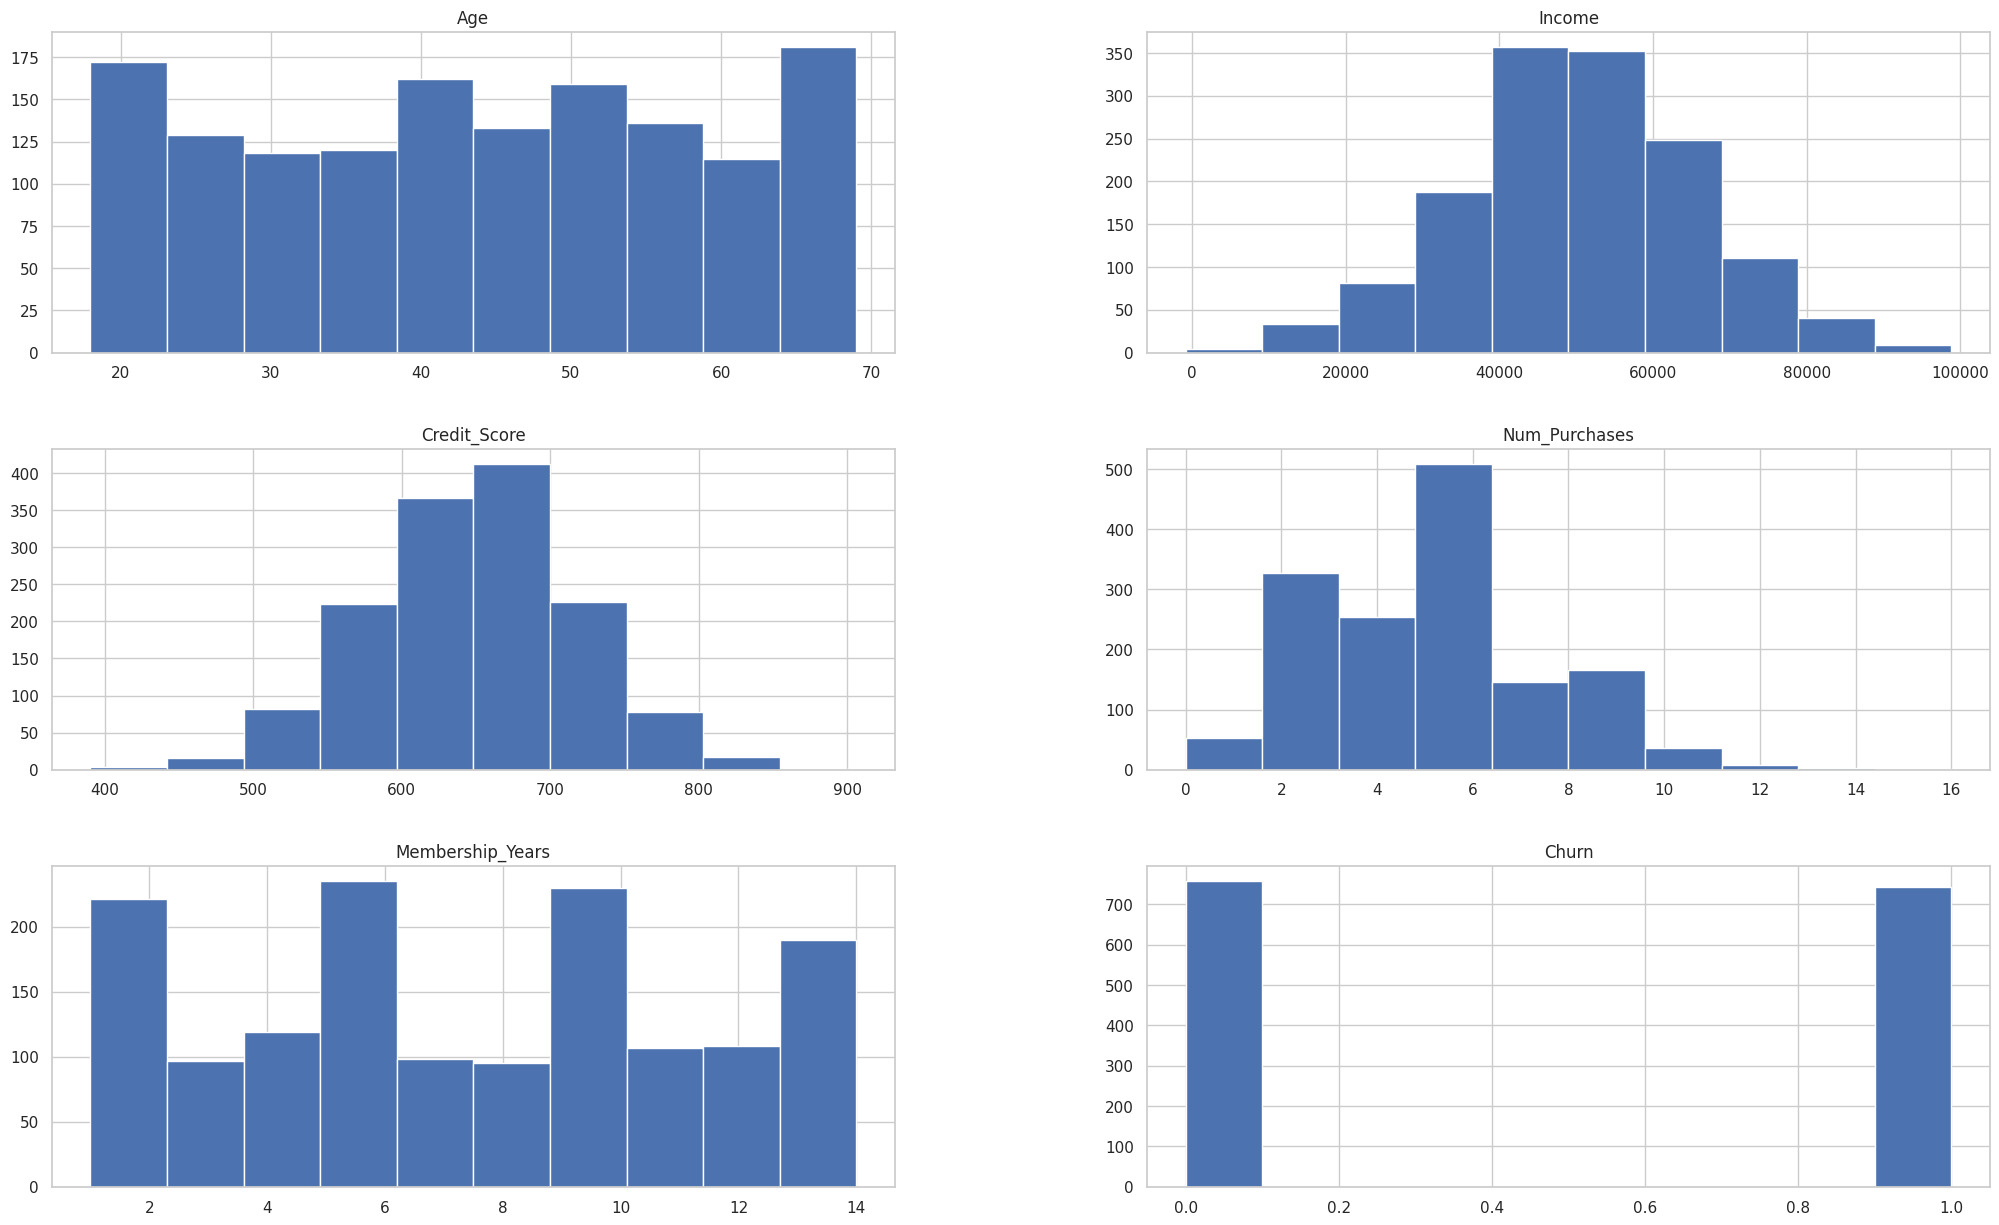

In [ ]:
#Data Analysis
%matplotlib inline
c1.hist(bins=10, figsize=(25,15))

In [ ]:
c1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1425 non-null   float64
 1   Income            1425 non-null   float64
 2   Gender            1425 non-null   object 
 3   Marital_Status    1500 non-null   object 
 4   Credit_Score      1425 non-null   float64
 5   Num_Purchases     1500 non-null   int64  
 6   Membership_Years  1500 non-null   int64  
 7   Device_Used       1500 non-null   object 
 8   Churn             1500 non-null   int64  
dtypes: float64(3), int64(3), object(3)
memory usage: 105.6+ KB


In [ ]:
#Data Preprocessing

# Handling missing values using SimpleImputer
imputer = SimpleImputer(strategy='mean')  # For numerical features
c1['Age'] = imputer.fit_transform(c1[['Age']])
c1['Income'] = imputer.fit_transform(c1[['Income']])
c1['Credit_Score'] = imputer.fit_transform(c1[['Credit_Score']])

# Handleg missing values for categorical variables
c1['Gender'] = c1['Gender'].fillna(c1['Gender'].mode()[0])  # Fill missing 'Gender' with mode

#Encoding Categorical Variables
label_encoder = LabelEncoder()
c1['Gender'] = label_encoder.fit_transform(c1['Gender'])
c1['Marital_Status'] = label_encoder.fit_transform(c1['Marital_Status'])
c1['Device_Used'] = label_encoder.fit_transform(c1['Device_Used'])

#Feature Scaling
scaler = StandardScaler()
numerical_features = ['Age', 'Income', 'Credit_Score', 'Num_Purchases', 'Membership_Years']
c1[numerical_features] = scaler.fit_transform(c1[numerical_features])

#Dataset Splitting
X = c1.drop('Churn', axis=1)  # Features
y = c1['Churn']  # Target variable

# Split the data into train and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


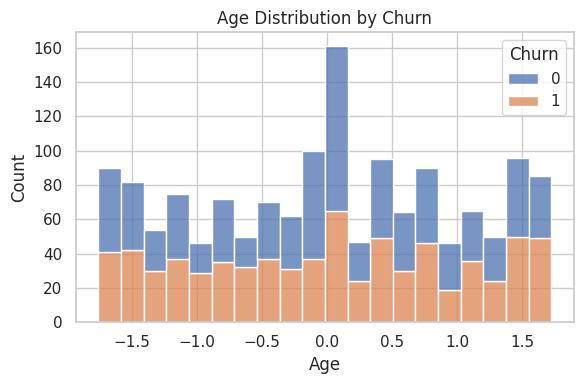

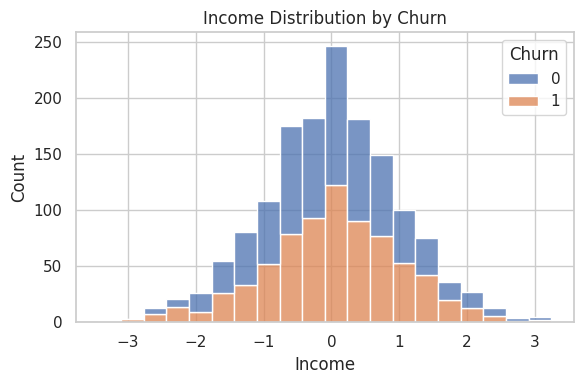

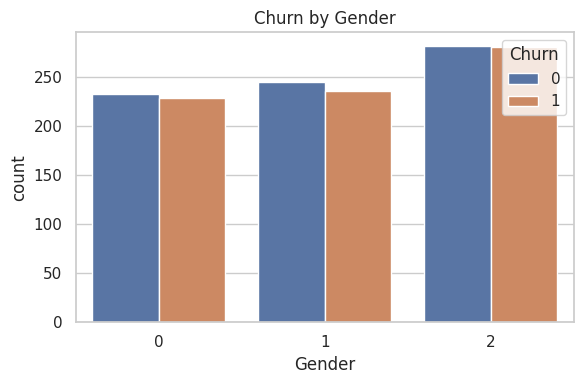

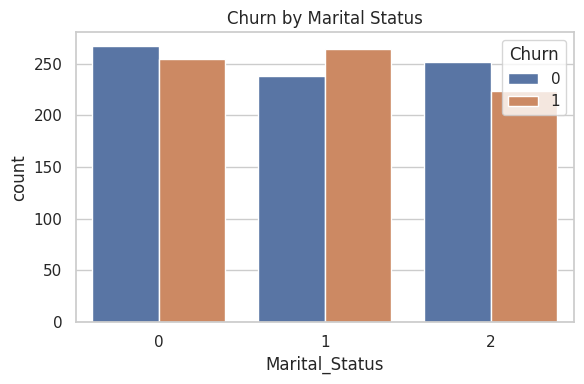

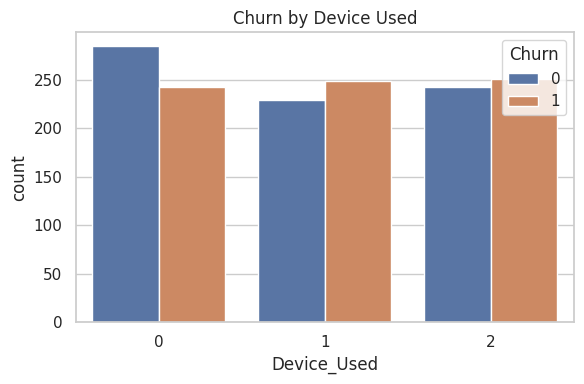

In [ ]:
#Data Analysis
sns.set(style="whitegrid")

# Age distribution by Churn
plt.figure(figsize=(6, 4))
sns.histplot(data=c1, x='Age', hue='Churn', multiple='stack', bins=20)
plt.title("Age Distribution by Churn")
plt.tight_layout()
plt.show()

# Income distribution by Churn
plt.figure(figsize=(6, 4))
sns.histplot(data=c1, x='Income', hue='Churn', multiple='stack', bins=20)
plt.title("Income Distribution by Churn")
plt.tight_layout()
plt.show()

# Churn by Gender
plt.figure(figsize=(6, 4))
sns.countplot(data=c1, x='Gender', hue='Churn')
plt.title("Churn by Gender")
plt.tight_layout()
plt.show()

# Churn by Marital Status
plt.figure(figsize=(6, 4))
sns.countplot(data=c1, x='Marital_Status', hue='Churn')
plt.title("Churn by Marital Status")
plt.tight_layout()
plt.show()

# Churn by Device Used
plt.figure(figsize=(6, 4))
sns.countplot(data=c1, x='Device_Used', hue='Churn')
plt.title("Churn by Device Used")
plt.tight_layout()
plt.show()


Dataset shape: (1500, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1500 non-null   float64
 1   Income            1500 non-null   float64
 2   Gender            1500 non-null   int64  
 3   Marital_Status    1500 non-null   int64  
 4   Credit_Score      1500 non-null   float64
 5   Num_Purchases     1500 non-null   float64
 6   Membership_Years  1500 non-null   float64
 7   Device_Used       1500 non-null   int64  
 8   Churn             1500 non-null   int64  
dtypes: float64(5), int64(4)
memory usage: 105.6 KB


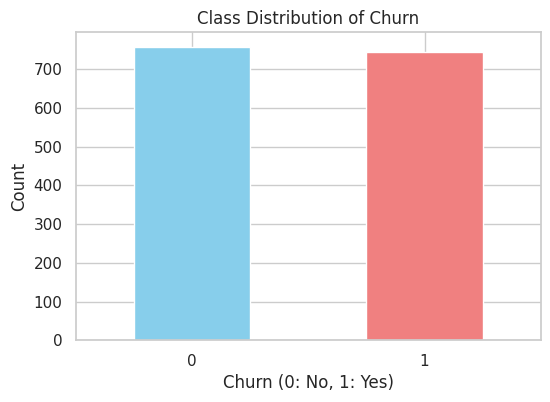

In [ ]:
# Dataset Description
print(f"Dataset shape: {c1.shape}")
c1.info()
c1.head()

#Exploratory Data Analysis (EDA)

# Check for class imbalance in the target variable 'Churn'
churn_counts = c1['Churn'].value_counts()

# Plot the distribution of the target variable using a bar chart
plt.figure(figsize=(6, 4))
churn_counts.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title("Class Distribution of Churn")
plt.xlabel("Churn (0: No, 1: Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

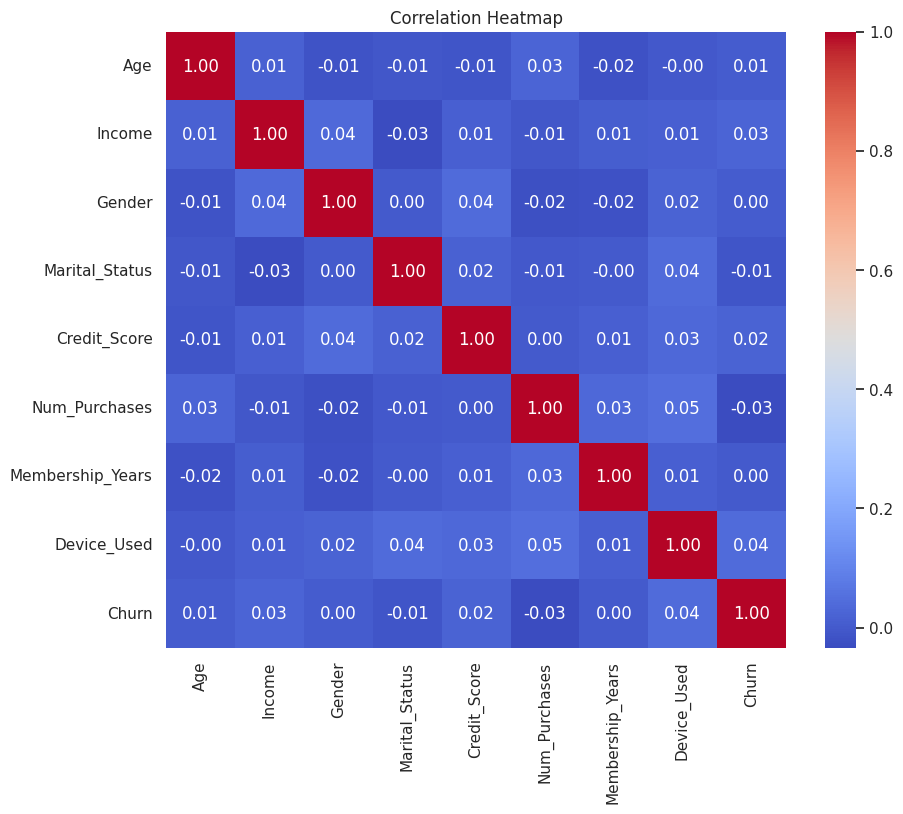

In [ ]:
# Correlation of all numerical features
numerical_features = c1.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = c1[numerical_features].corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Model Training
# 2. Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)
y_pred_tree = decision_tree.predict(X_test)

# 3. Logistic Regression
from sklearn.linear_model import LogisticRegression
logistic_regression = LogisticRegression()
logistic_regression.fit(X_train, y_train)
y_pred_lr = logistic_regression.predict(X_test)

# 4. Naive Bayes Classifier
from sklearn.naive_bayes import GaussianNB
naive_bayes = GaussianNB()
naive_bayes.fit(X_train, y_train)
y_pred_nb = naive_bayes.predict(X_test)

# 5. Neural Network Classifier (MLP)
from sklearn.neural_network import MLPClassifier
neural_network = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500)
neural_network.fit(X_train, y_train)
y_pred_nn = neural_network.predict(X_test)


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


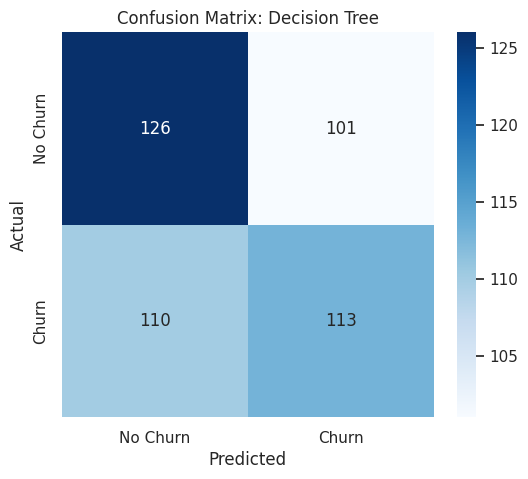


=== Decision Tree ===
Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.55      0.54       227
           1       0.53      0.52      0.52       223

    accuracy                           0.53       450
   macro avg       0.53      0.53      0.53       450
weighted avg       0.53      0.53      0.53       450



In [ ]:
# 2. Decision Tree Classifier
cm_tree = confusion_matrix(y_test, y_pred_tree)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Blues", xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title('Confusion Matrix: Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report for Decision Tree
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)
y_pred_tree = decision_tree.predict(X_test)


print("\n=== Decision Tree ===")
print("Classification Report:\n", classification_report(y_test, y_pred_tree))

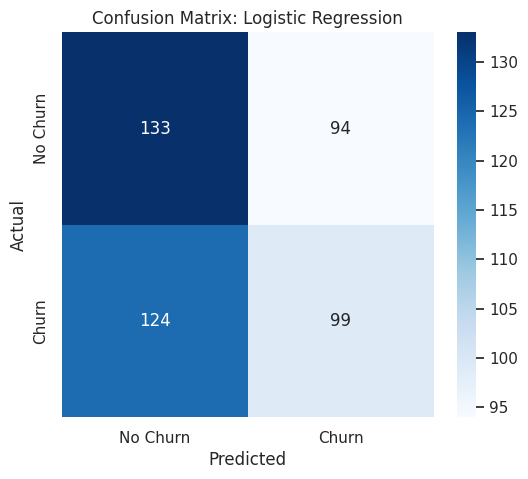


=== Logistic Regression ===
Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.59      0.55       227
           1       0.51      0.44      0.48       223

    accuracy                           0.52       450
   macro avg       0.52      0.51      0.51       450
weighted avg       0.52      0.52      0.51       450



In [ ]:
# 3. Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

logistic_regression = LogisticRegression()
logistic_regression.fit(X_train, y_train)
y_pred_lr = logistic_regression.predict(X_test)

# Classification Report for Logistic Regression
print("\n=== Logistic Regression ===")
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

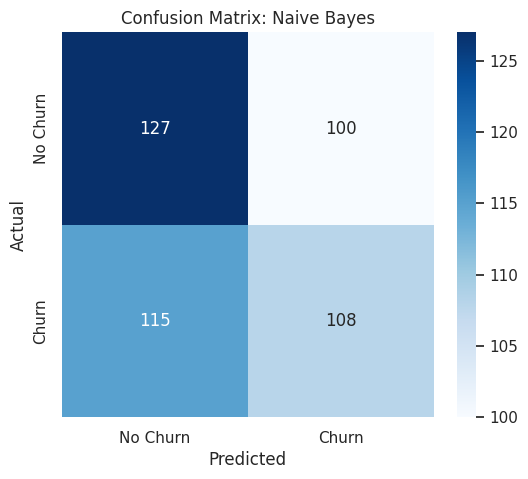


=== Naive Bayes ===
Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.56      0.54       227
           1       0.52      0.48      0.50       223

    accuracy                           0.52       450
   macro avg       0.52      0.52      0.52       450
weighted avg       0.52      0.52      0.52       450



In [ ]:
# 4. Naive Bayes Classifier
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues", xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title('Confusion Matrix: Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

naive_bayes = GaussianNB()
naive_bayes.fit(X_train, y_train)
y_pred_nb = naive_bayes.predict(X_test)

# Classification Report for Naive Bayes
print("\n=== Naive Bayes ===")
print("Classification Report:\n", classification_report(y_test, y_pred_nb))

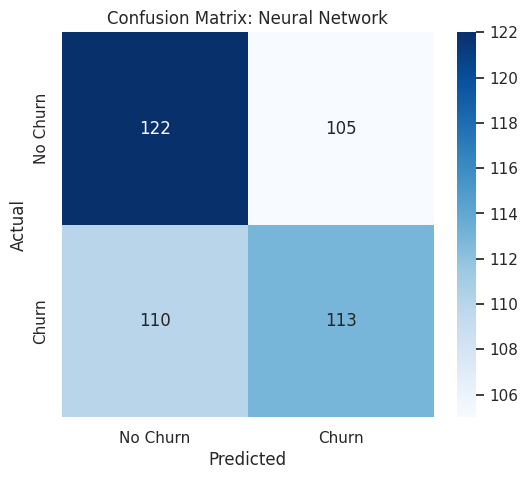


=== Neural Network ===
Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.56      0.53       227
           1       0.50      0.46      0.48       223

    accuracy                           0.51       450
   macro avg       0.51      0.51      0.51       450
weighted avg       0.51      0.51      0.51       450



/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# 5. Neural Network Classifier (MLP)
cm_nn = confusion_matrix(y_test, y_pred_nn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nn, annot=True, fmt="d", cmap="Blues", xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title('Confusion Matrix: Neural Network')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# 5. Neural Network Classifier (MLP)
neural_network = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500)
neural_network.fit(X_train, y_train)
y_pred_nn = neural_network.predict(X_test)

# Classification Report for Neural Network
print("\n=== Neural Network ===")
print("Classification Report:\n", classification_report(y_test, y_pred_nn))

MODEL

In [ ]:
#Model Evaluation
# Evaluate accuracy, precision, recall, and AUC for each model

# Decision Tree Evaluation

accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree, recall_tree, _ = precision_recall_curve(y_test, decision_tree.predict_proba(X_test)[:, 1])
auc_tree = roc_auc_score(y_test, decision_tree.predict_proba(X_test)[:, 1])
fpr_tree, tpr_tree, _ = roc_curve(y_test, decision_tree.predict_proba(X_test)[:, 1])
# Print the AUC score
print("Decision Tree AUC:", auc_tree)

# Logistic Regression Evaluation

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr, recall_lr, _ = precision_recall_curve(y_test, logistic_regression.predict_proba(X_test)[:, 1])
auc_lr = roc_auc_score(y_test, logistic_regression.predict_proba(X_test)[:, 1])
fpr_lr, tpr_lr, _ = roc_curve(y_test, logistic_regression.predict_proba(X_test)[:, 1])
# Print the AUC score
print("Logistic Regression AUC:", auc_lr)

# Naive Bayes Evaluation

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb, recall_nb, _ = precision_recall_curve(y_test, naive_bayes.predict_proba(X_test)[:, 1])
auc_nb = roc_auc_score(y_test, naive_bayes.predict_proba(X_test)[:, 1])
fpr_nb, tpr_nb, _ = roc_curve(y_test, naive_bayes.predict_proba(X_test)[:, 1])
# Print the AUC score
print("Naive Bayes AUC:", auc_nb)

# Neural Network Evaluation
accuracy_nn = accuracy_score(y_test, y_pred_nn)
precision_nn, recall_nn, _ = precision_recall_curve(y_test, neural_network.predict_proba(X_test)[:, 1])
auc_nn = roc_auc_score(y_test, neural_network.predict_proba(X_test)[:, 1])
fpr_nn, tpr_nn, _ = roc_curve(y_test, neural_network.predict_proba(X_test)[:, 1])
# Print the AUC score
print("Neural Network AUC:", auc_nn)

Decision Tree AUC: 0.5309752869362517
Logistic Regression AUC: 0.5012741747496099
Naive Bayes AUC: 0.5191126212441477
Neural Network AUC: 0.5090772604255152


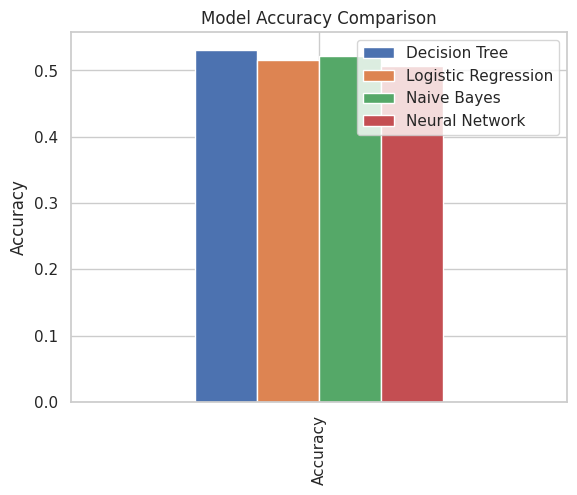

In [ ]:
#Model Comparison
# 1. Plot accuracy of all models
accuracy_df = pd.DataFrame({
    'Decision Tree': accuracy_tree,
    'Logistic Regression': accuracy_lr,
    'Naive Bayes': accuracy_nb,
    'Neural Network': accuracy_nn
}, index=['Accuracy'])

accuracy_df.plot(kind='bar', title="Model Accuracy Comparison")
plt.ylabel('Accuracy')
plt.show()

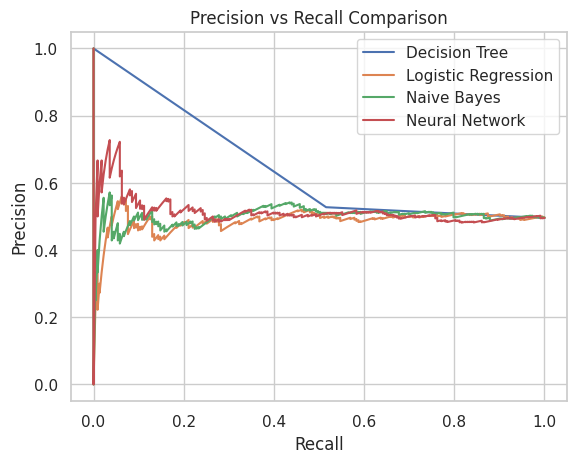

In [ ]:
# 2. Precision and Recall Comparison for each model

plt.plot(recall_tree, precision_tree, label='Decision Tree')
plt.plot(recall_lr, precision_lr, label='Logistic Regression')
plt.plot(recall_nb, precision_nb, label='Naive Bayes')
plt.plot(recall_nn, precision_nn, label='Neural Network')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision vs Recall Comparison')
plt.legend()
plt.show()

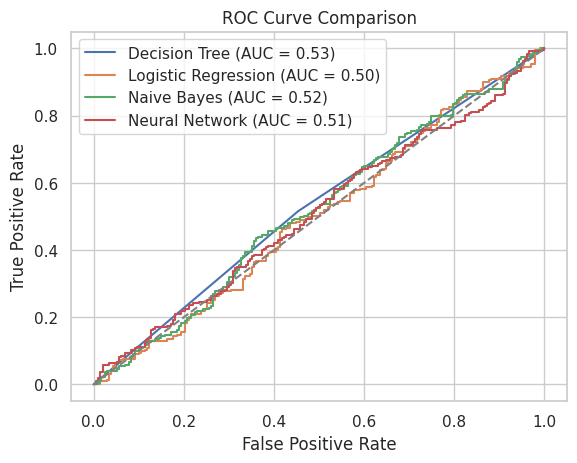

In [ ]:
plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC = {auc_tree:.2f})')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.2f})')
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc_nn:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Random model
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()